# Análisis relacional de burnout estudiantil

Este notebook analiza las relaciones entre las variables del dataset **AI Dependency, Career Anxiety and Student Burnout** y la variable objetivo `burnout_score`.

La pregunta guía es:

**¿Qué variables del dataset se relacionan con mayores niveles de burnout estudiantil y cómo pueden estas relaciones orientar una futura etapa de modelamiento predictivo?**

**Hipótesis inicial:** los estudiantes con mayor dependencia de IA, mayor ansiedad profesional, mayor estrés y menor motivación tenderán a presentar mayores niveles de burnout.

El análisis es exploratorio. Las asociaciones observadas no deben interpretarse como causalidad; su utilidad principal es identificar patrones y variables candidatas para etapas posteriores de machine learning.

## 1. Configuración y carga de datos

Se cargan las librerías principales y el dataset limpio generado en la etapa de calidad de datos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "dataset_limpio.csv").exists():
    PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_limpio.csv"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tablas"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "burnout_score"

df = pd.read_csv(DATA_PATH)

if TARGET not in df.columns:
    raise ValueError(f"La variable objetivo {TARGET!r} no existe en el dataset.")

display(Markdown(f"Dataset cargado desde `{DATA_PATH}`."))
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
df.head()

Dataset cargado desde `/home/chop/Ufro/proyecto-ingenieria-datos/data/processed/dataset_limpio.csv`.

Filas: 11,119
Columnas: 30


,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


In [2]:
validation_summary = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "n_unicos": df.nunique(dropna=True).values,
})

duplicated_rows = int(df.duplicated().sum())

display(validation_summary)
display(Markdown(f"Filas duplicadas exactas detectadas: **{duplicated_rows}**."))

,variable,dtype,nulos,n_unicos
0,student_id,str,0,11119
1,age,int64,0,11
2,gender,str,0,3
3,degree_type,str,0,4
4,stream,str,0,4
5,year_of_study,int64,0,4
6,college_tier,str,0,3
7,urban_or_rural,str,0,2
8,daily_ai_tool_usage_hrs,float64,0,79
9,primary_ai_tools_used,str,0,5


Filas duplicadas exactas detectadas: **0**.

## 2. Selección de variables

Se separan variables numéricas y categóricas porque requieren técnicas de análisis distintas. `student_id` se excluye porque funciona como identificador y no como variable explicativa.

Las variables categóricas `gender`, `degree_type`, `year_of_study` y `urban_or_rural` se revisan como variables descriptivas secundarias, pero no se priorizan en las visualizaciones principales porque tienen menor conexión conceptual directa con la hipótesis del análisis. La variable `age` no se prioriza en el análisis relacional principal porque el foco del estudio está en dimensiones académicas, uso de IA, ansiedad profesional y bienestar estudiantil. Puede considerarse como variable de control en etapas posteriores.

La sección de comparaciones se concentra en uso de IA, herramienta principal, área de estudio y tipo de institución.

In [3]:
numeric_vars = [
    "daily_ai_tool_usage_hrs",
    "ai_replaces_own_thinking_score",
    "ai_dependency_score",
    "placement_anxiety_score",
    "fear_of_job_loss_to_ai",
    "career_clarity_score",
    "weekly_job_application_count",
    "resume_confidence_score",
    "interview_anxiety_score",
    "daily_study_hours",
    "self_learning_hours_per_week",
    "skill_development_courses_taken",
    "social_media_hrs_per_day",
    "sleep_hours",
    "stress_level",
    "motivation_score",
    "seeks_career_counseling",
    "overall_career_readiness_score",
    "burnout_score",
]

categorical_vars = [
    "gender",
    "degree_type",
    "stream",
    "year_of_study",
    "college_tier",
    "urban_or_rural",
    "primary_ai_tools_used",
    "uses_ai_for_assignments",
]

missing_numeric = sorted(set(numeric_vars) - set(df.columns))
missing_categorical = sorted(set(categorical_vars) - set(df.columns))
if missing_numeric or missing_categorical:
    raise ValueError(
        "Faltan variables esperadas. "
        f"Numéricas: {missing_numeric}. Categóricas: {missing_categorical}."
    )

analysis_df = df.copy()
for col in numeric_vars:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df["year_of_study"] = analysis_df["year_of_study"].astype(str)
analysis_df["seeks_career_counseling_label"] = analysis_df["seeks_career_counseling"].map({
    0.0: "No busca orientación",
    1.0: "Busca orientación",
})

display(Markdown("**Variables numéricas seleccionadas:**"))
display(pd.DataFrame({"variable": numeric_vars}))
display(Markdown("**Variables categóricas seleccionadas:**"))
display(pd.DataFrame({"variable": categorical_vars}))

**Variables numéricas seleccionadas:**

,variable
0,daily_ai_tool_usage_hrs
1,ai_replaces_own_thinking_score
2,ai_dependency_score
3,placement_anxiety_score
4,fear_of_job_loss_to_ai
5,career_clarity_score
6,weekly_job_application_count
7,resume_confidence_score
8,interview_anxiety_score
9,daily_study_hours


**Variables categóricas seleccionadas:**

,variable
0,gender
1,degree_type
2,stream
3,year_of_study
4,college_tier
5,urban_or_rural
6,primary_ai_tools_used
7,uses_ai_for_assignments


### 2.1 Variables descriptivas secundarias

La siguiente tabla resume `gender`, `degree_type`, `year_of_study`, `urban_or_rural` y `age` frente a `burnout_score`. Se incluye como apoyo descriptivo, pero estas variables no se profundizan en los gráficos principales por la delimitación conceptual del análisis.

In [4]:
secondary_descriptive_vars = [
    "gender",
    "degree_type",
    "year_of_study",
    "urban_or_rural",
    "age",
]

missing_secondary = sorted(set(secondary_descriptive_vars) - set(df.columns))
if missing_secondary:
    raise ValueError(f"Faltan variables secundarias esperadas: {missing_secondary}.")

secondary_rows = []
for var in secondary_descriptive_vars:
    temp = analysis_df.copy()
    if var == "age":
        temp[var] = pd.to_numeric(temp[var], errors="coerce")
        tipo = "numérica agrupada por valor"
    else:
        tipo = "categórica"

    summary = (
        temp.groupby(var, observed=True)[TARGET]
        .agg(count="count", mean="mean", median="median")
        .reset_index()
        .rename(columns={var: "categoria"})
    )
    summary["variable"] = var
    summary["tipo"] = tipo
    secondary_rows.append(summary[["variable", "tipo", "categoria", "count", "mean", "median"]])

resumen_secundario_variables = pd.concat(secondary_rows, ignore_index=True)
resumen_secundario_variables["mean"] = resumen_secundario_variables["mean"].round(2)
resumen_secundario_variables["median"] = resumen_secundario_variables["median"].round(2)
resumen_secundario_variables.to_csv(
    OUTPUT_TABLES_DIR / "resumen_secundario_variables_no_priorizadas.csv",
    index=False,
)

display(resumen_secundario_variables)

,variable,tipo,categoria,count,mean,median
0,gender,categórica,Female,4993,5.65,6.0
1,gender,categórica,Male,5815,5.64,6.0
2,gender,categórica,Non-binary,311,5.56,5.0
3,degree_type,categórica,B.Sc/B.A/B.Com,3357,5.66,6.0
4,degree_type,categórica,B.Tech/B.E.,4990,5.61,6.0
5,degree_type,categórica,M.Tech/M.Sc,1703,5.71,6.0
6,degree_type,categórica,MBA,1069,5.63,6.0
7,year_of_study,categórica,1,3715,5.76,6.0
8,year_of_study,categórica,2,3748,5.61,6.0
9,year_of_study,categórica,3,2416,5.58,6.0


## 3. Correlaciones entre variables numéricas

Se utiliza correlación de Spearman porque varias variables corresponden a puntajes o escalas ordinales. Esto permite detectar asociaciones monotónicas sin asumir normalidad.

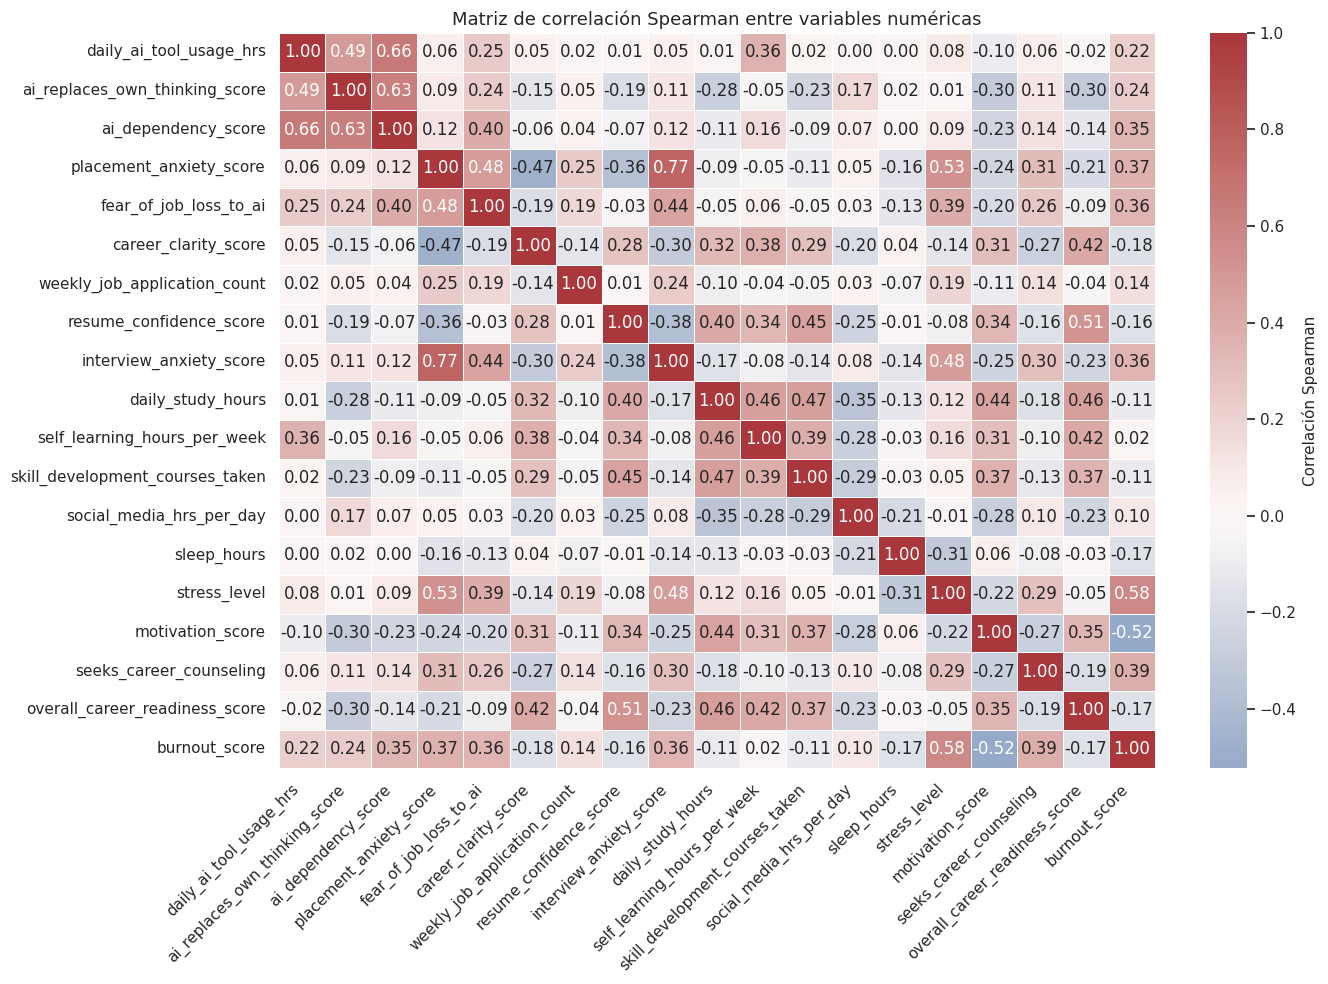

In [5]:
corr_spearman = analysis_df[numeric_vars].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_spearman,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Correlación Spearman"},
)
plt.title("Matriz de correlación Spearman entre variables numéricas")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
ranking_correlaciones = (
    corr_spearman[TARGET]
    .drop(labels=[TARGET])
    .rename("correlacion_spearman")
    .reset_index()
    .rename(columns={"index": "variable"})
)
ranking_correlaciones["correlacion_abs"] = ranking_correlaciones["correlacion_spearman"].abs()
ranking_correlaciones["direccion"] = np.where(
    ranking_correlaciones["correlacion_spearman"] > 0,
    "positiva",
    "negativa",
)
ranking_correlaciones = ranking_correlaciones.sort_values(
    "correlacion_abs", ascending=False
).reset_index(drop=True)

ranking_correlaciones.to_csv(OUTPUT_TABLES_DIR / "ranking_correlaciones_burnout.csv", index=False)
display(ranking_correlaciones)

,variable,correlacion_spearman,correlacion_abs,direccion
0,stress_level,0.577417,0.577417,positiva
1,motivation_score,-0.523542,0.523542,negativa
2,seeks_career_counseling,0.386275,0.386275,positiva
3,placement_anxiety_score,0.370386,0.370386,positiva
4,interview_anxiety_score,0.355644,0.355644,positiva
5,fear_of_job_loss_to_ai,0.355073,0.355073,positiva
6,ai_dependency_score,0.350719,0.350719,positiva
7,ai_replaces_own_thinking_score,0.243362,0.243362,positiva
8,daily_ai_tool_usage_hrs,0.224645,0.224645,positiva
9,career_clarity_score,-0.177901,0.177901,negativa


In [7]:
def interpretar_correlaciones(ranking: pd.DataFrame, top_n: int = 5) -> str:
    top = ranking.head(top_n).copy()
    strongest = top.iloc[0]
    positives = ranking[ranking["correlacion_spearman"] > 0].head(3)
    negatives = ranking[ranking["correlacion_spearman"] < 0].head(3)

    lines = [
        "### Interpretación del ranking de correlaciones",
        f"La variable con mayor asociación monotónica con `{TARGET}` es `{strongest['variable']}` "
        f"(Spearman = {strongest['correlacion_spearman']:.3f}).",
    ]
    if not positives.empty:
        pos_txt = ", ".join(
            f"`{row.variable}` ({row.correlacion_spearman:.3f})"
            for row in positives.itertuples(index=False)
        )
        lines.append(f"Las principales relaciones positivas son: {pos_txt}. Esto sugiere que valores más altos de esas variables tienden a coexistir con mayor burnout.")
    if not negatives.empty:
        neg_txt = ", ".join(
            f"`{row.variable}` ({row.correlacion_spearman:.3f})"
            for row in negatives.itertuples(index=False)
        )
        lines.append(f"Las principales relaciones negativas son: {neg_txt}. Esto sugiere que valores más altos de esas variables tienden a coexistir con menor burnout.")
    lines.append("Estas relaciones son exploratorias y no implican causalidad. Variables conceptualmente relevantes pueden seguir siendo útiles para modelamiento aunque su correlación bivariada sea baja.")
    return "\n\n".join(lines)

display(Markdown(interpretar_correlaciones(ranking_correlaciones)))

### Interpretación del ranking de correlaciones

La variable con mayor asociación monotónica con `burnout_score` es `stress_level` (Spearman = 0.577).

Las principales relaciones positivas son: `stress_level` (0.577), `seeks_career_counseling` (0.386), `placement_anxiety_score` (0.370). Esto sugiere que valores más altos de esas variables tienden a coexistir con mayor burnout.

Las principales relaciones negativas son: `motivation_score` (-0.524), `career_clarity_score` (-0.178), `overall_career_readiness_score` (-0.170). Esto sugiere que valores más altos de esas variables tienden a coexistir con menor burnout.

Estas relaciones son exploratorias y no implican causalidad. Variables conceptualmente relevantes pueden seguir siendo útiles para modelamiento aunque su correlación bivariada sea baja.

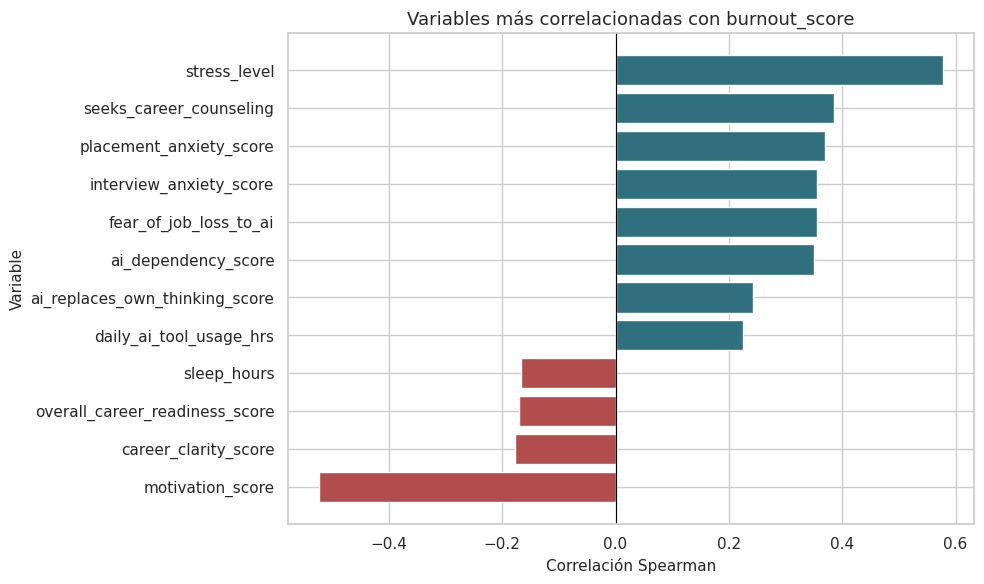

In [8]:
plt.figure(figsize=(10, 6))
bar_df = ranking_correlaciones.head(12).sort_values("correlacion_spearman")
colors = np.where(bar_df["correlacion_spearman"] >= 0, "#2f6f7e", "#b14d4d")
plt.barh(bar_df["variable"], bar_df["correlacion_spearman"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Variables más correlacionadas con burnout_score")
plt.xlabel("Correlación Spearman")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 4. Relaciones bivariadas con `burnout_score`

Los siguientes gráficos permiten observar tendencias entre `burnout_score` y variables numéricas clave. Cada interpretación describe el patrón observado sin asumir causalidad.

La línea de tendencia se usa solo como apoyo visual. En variables que corresponden a escalas discretas, como `stress_level`, `motivation_score`, `ai_dependency_score`, `placement_anxiety_score`, `interview_anxiety_score` y `fear_of_job_loss_to_ai`, la línea no debe interpretarse como una relación exacta.

Además, algunas variables como `stress_level`, `motivation_score` y `overall_career_readiness_score` están conceptualmente muy próximas al bienestar académico o profesional. En una etapa de modelamiento conviene evaluar modelos con y sin estas variables para comprobar cuánto dependen las predicciones de indicadores cercanos al propio burnout.

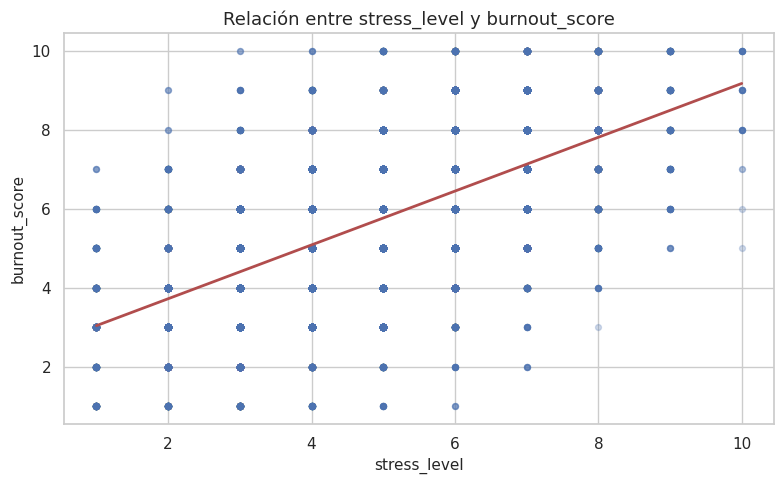

**Interpretación:** `stress_level` muestra una relación positiva fuerte con `burnout_score` (Spearman = 0.577). En este dataset, valores más altos de `stress_level` tienden a observarse junto con mayor burnout. Se observa una tendencia positiva entre ambas variables, aunque la dispersión indica que la relación debe interpretarse como exploratoria, no exacta ni causal. Además, esta variable corresponde a una escala discreta, por lo que la línea de tendencia debe leerse solo como una guía visual.

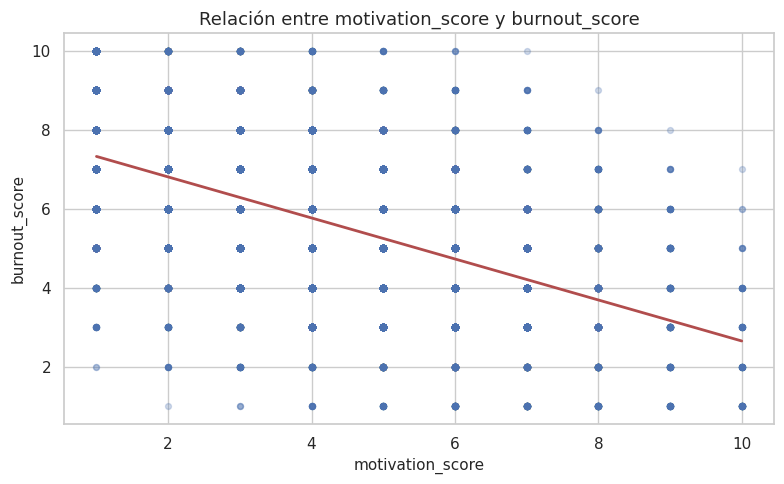

**Interpretación:** `motivation_score` muestra una relación negativa fuerte con `burnout_score` (Spearman = -0.524). En este dataset, valores más altos de `motivation_score` tienden a observarse junto con menor burnout. Se observa una tendencia negativa entre ambas variables, aunque la dispersión indica que la relación debe interpretarse como exploratoria, no exacta ni causal. Además, esta variable corresponde a una escala discreta, por lo que la línea de tendencia debe leerse solo como una guía visual.

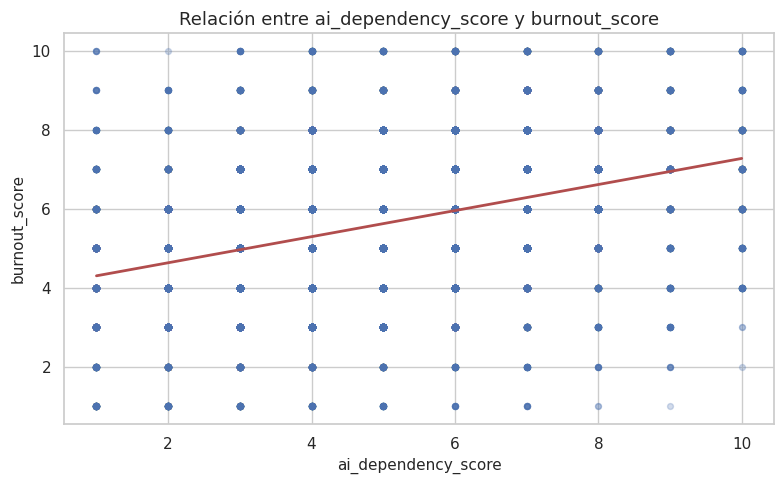

**Interpretación:** `ai_dependency_score` muestra una relación positiva moderada con `burnout_score` (Spearman = 0.351). En este dataset, valores más altos de `ai_dependency_score` tienden a observarse junto con mayor burnout. Se observa una tendencia positiva entre ambas variables, aunque la dispersión indica que la relación debe interpretarse como exploratoria, no exacta ni causal. Además, esta variable corresponde a una escala discreta, por lo que la línea de tendencia debe leerse solo como una guía visual.

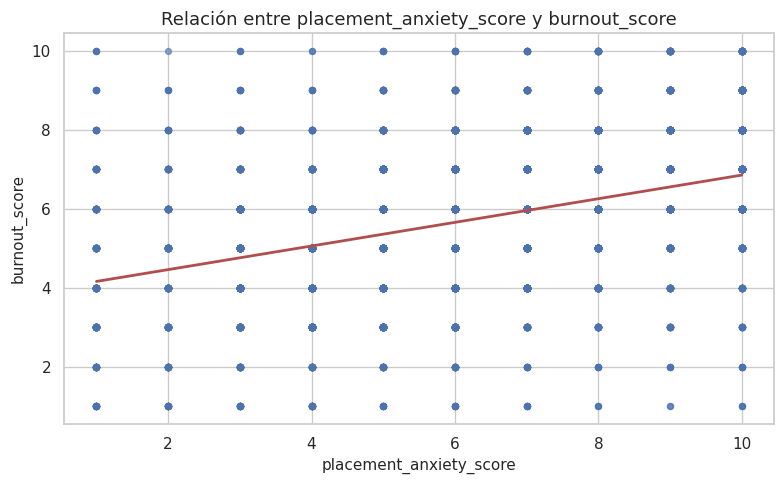

**Interpretación:** `placement_anxiety_score` muestra una relación positiva moderada con `burnout_score` (Spearman = 0.370). En este dataset, valores más altos de `placement_anxiety_score` tienden a observarse junto con mayor burnout. Se observa una tendencia positiva entre ambas variables, aunque la dispersión indica que la relación debe interpretarse como exploratoria, no exacta ni causal. Además, esta variable corresponde a una escala discreta, por lo que la línea de tendencia debe leerse solo como una guía visual.

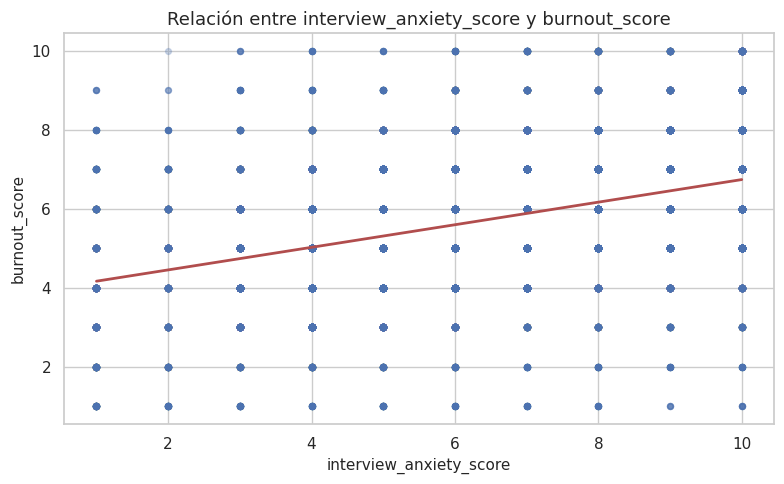

**Interpretación:** `interview_anxiety_score` muestra una relación positiva moderada con `burnout_score` (Spearman = 0.356). En este dataset, valores más altos de `interview_anxiety_score` tienden a observarse junto con mayor burnout. Se observa una tendencia positiva entre ambas variables, aunque la dispersión indica que la relación debe interpretarse como exploratoria, no exacta ni causal. Además, esta variable corresponde a una escala discreta, por lo que la línea de tendencia debe leerse solo como una guía visual.

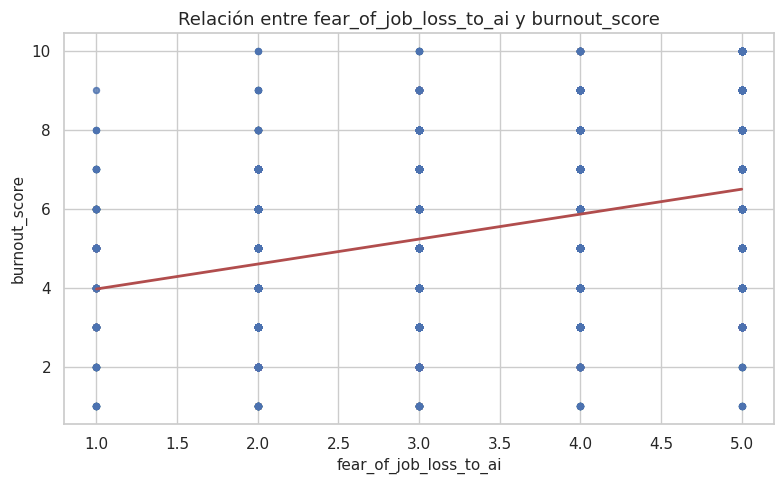

**Interpretación:** `fear_of_job_loss_to_ai` muestra una relación positiva moderada con `burnout_score` (Spearman = 0.355). En este dataset, valores más altos de `fear_of_job_loss_to_ai` tienden a observarse junto con mayor burnout. Se observa una tendencia positiva entre ambas variables, aunque la dispersión indica que la relación debe interpretarse como exploratoria, no exacta ni causal. Además, esta variable corresponde a una escala discreta, por lo que la línea de tendencia debe leerse solo como una guía visual.

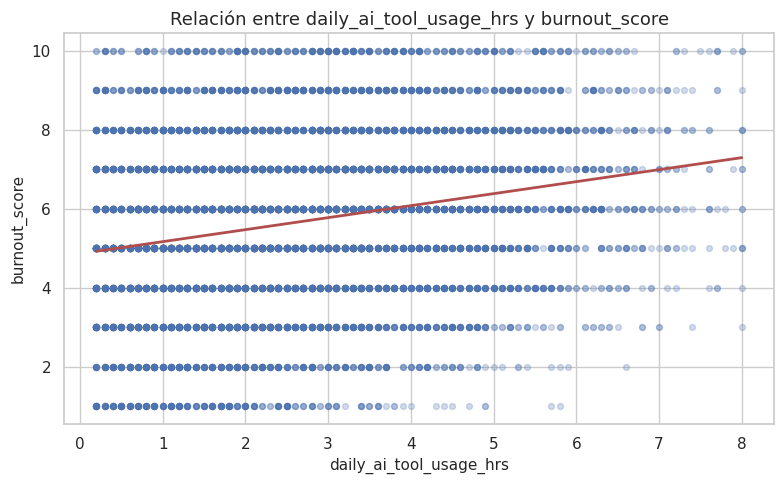

**Interpretación:** `daily_ai_tool_usage_hrs` muestra una relación positiva débil con `burnout_score` (Spearman = 0.225). En este dataset, valores más altos de `daily_ai_tool_usage_hrs` tienden a observarse junto con mayor burnout. Se observa una tendencia positiva entre ambas variables, aunque la dispersión indica que la relación debe interpretarse como exploratoria, no exacta ni causal.

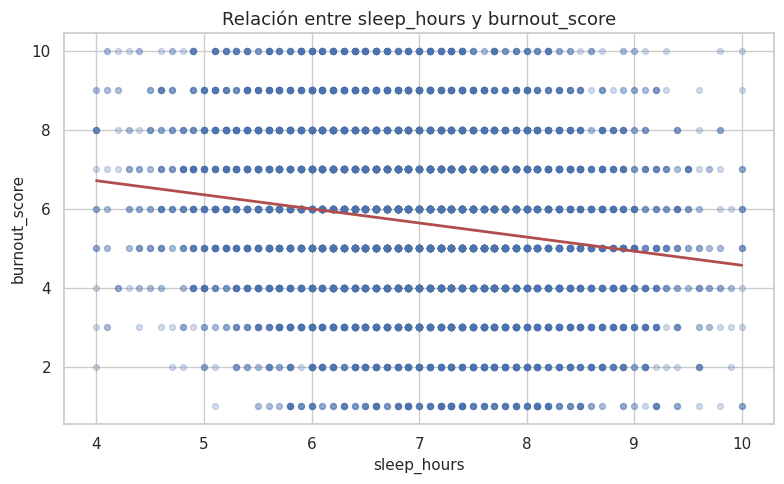

**Interpretación:** `sleep_hours` muestra una relación negativa débil con `burnout_score` (Spearman = -0.167). En este dataset, valores más altos de `sleep_hours` tienden a observarse junto con menor burnout. Se observa una tendencia negativa entre ambas variables, aunque la dispersión indica que la relación debe interpretarse como exploratoria, no exacta ni causal.

In [9]:
scatter_vars = [
    "stress_level",
    "motivation_score",
    "ai_dependency_score",
    "placement_anxiety_score",
    "interview_anxiety_score",
    "fear_of_job_loss_to_ai",
    "daily_ai_tool_usage_hrs",
    "sleep_hours",
]

discrete_scale_vars = {
    "stress_level",
    "motivation_score",
    "ai_dependency_score",
    "placement_anxiety_score",
    "interview_anxiety_score",
    "fear_of_job_loss_to_ai",
}

def describe_numeric_relationship(var: str) -> str:
    corr = ranking_correlaciones.loc[
        ranking_correlaciones["variable"] == var, "correlacion_spearman"
    ].iloc[0]
    if abs(corr) >= 0.50:
        strength = "fuerte"
    elif abs(corr) >= 0.30:
        strength = "moderada"
    elif abs(corr) >= 0.10:
        strength = "débil"
    else:
        strength = "muy débil"
    direction = "positiva" if corr > 0 else "negativa"
    meaning = "mayor burnout" if corr > 0 else "menor burnout"
    caution = (
        " Además, esta variable corresponde a una escala discreta, por lo que la línea de tendencia "
        "debe leerse solo como una guía visual."
        if var in discrete_scale_vars
        else ""
    )
    return (
        f"**Interpretación:** `{var}` muestra una relación {direction} {strength} "
        f"con `{TARGET}` (Spearman = {corr:.3f}). En este dataset, valores más altos de `{var}` "
        f"tienden a observarse junto con {meaning}. Se observa una tendencia {direction} entre ambas variables, "
        f"aunque la dispersión indica que la relación debe interpretarse como exploratoria, no exacta ni causal."
        f"{caution}"
    )

for var in scatter_vars:
    plt.figure(figsize=(8, 5))
    sns.regplot(
        data=analysis_df,
        x=var,
        y=TARGET,
        scatter_kws={"alpha": 0.25, "s": 18},
        line_kws={"color": "#b14d4d", "linewidth": 2},
        ci=None,
    )
    plt.title(f"Relación entre {var} y {TARGET}")
    plt.xlabel(var)
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()
    display(Markdown(describe_numeric_relationship(var)))

## 5. Comparaciones de burnout entre grupos

Antes de interpretar cada boxplot se revisan tablas con `count`, `mean`, `median`, `std`, `min` y `max`. El tamaño de grupo es parte de la interpretación: una media calculada con pocos registros puede ser menos representativa.

También se incluye `seeks_career_counseling` porque muestra una asociación relevante con `burnout_score`. Esta variable se interpreta con cautela: puede reflejar una respuesta posterior al malestar académico o laboral, más que una variable explicativa previa.

In [10]:
AI_USAGE_ORDER = ["Never", "Rarely", "Sometimes", "Frequently", "Always"]
CAREER_COUNSELING_ORDER = ["No busca orientación", "Busca orientación"]
MIN_GROUP_SIZE_FOR_INTERPRETATION = 30

analysis_df["uses_ai_for_assignments"] = pd.Categorical(
    analysis_df["uses_ai_for_assignments"],
    categories=AI_USAGE_ORDER,
    ordered=True,
)
analysis_df["seeks_career_counseling_label"] = pd.Categorical(
    analysis_df["seeks_career_counseling_label"],
    categories=CAREER_COUNSELING_ORDER,
    ordered=True,
)

def group_summary(variable: str) -> pd.DataFrame:
    summary = (
        analysis_df.groupby(variable, observed=True)[TARGET]
        .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
        .reset_index()
    )
    summary["mean"] = summary["mean"].round(2)
    summary["median"] = summary["median"].round(2)
    summary["std"] = summary["std"].round(2)
    return summary

summaries = {
    "uses_ai_for_assignments": group_summary("uses_ai_for_assignments"),
    "primary_ai_tools_used": group_summary("primary_ai_tools_used"),
    "stream": group_summary("stream"),
    "college_tier": group_summary("college_tier"),
    "seeks_career_counseling_label": group_summary("seeks_career_counseling_label"),
}

export_paths = {
    "uses_ai_for_assignments": "burnout_por_uso_ia.csv",
    "primary_ai_tools_used": "burnout_por_herramienta_ia.csv",
    "stream": "burnout_por_stream.csv",
    "college_tier": "burnout_por_college_tier.csv",
    "seeks_career_counseling_label": "burnout_por_orientacion_carrera.csv",
}

for key, summary in summaries.items():
    summary.to_csv(OUTPUT_TABLES_DIR / export_paths[key], index=False)

### frecuencia de uso de IA para tareas académicas

,uses_ai_for_assignments,count,mean,median,std,min,max
0,Never,1315,5.00,5.0,2.05,1,10
1,Rarely,3945,5.28,5.0,2.04,1,10
2,Sometimes,3400,5.82,6.0,2.00,1,10
3,Frequently,1780,6.19,6.0,1.95,1,10
4,Always,679,6.64,7.0,1.95,1,10


**Interpretación de tamaños de grupo para frecuencia de uso de IA para tareas académicas:**

La media más alta de burnout aparece en `Always` (media = 6.64, n = 679).

La media más baja aparece en `Never` (media = 5.00, n = 1315).

Todas las categorías tienen al menos 30 registros, por lo que las comparaciones descriptivas tienen un respaldo razonable en tamaño muestral.

Estas diferencias son descriptivas; no constituyen evidencia causal ni una prueba estadística inferencial.

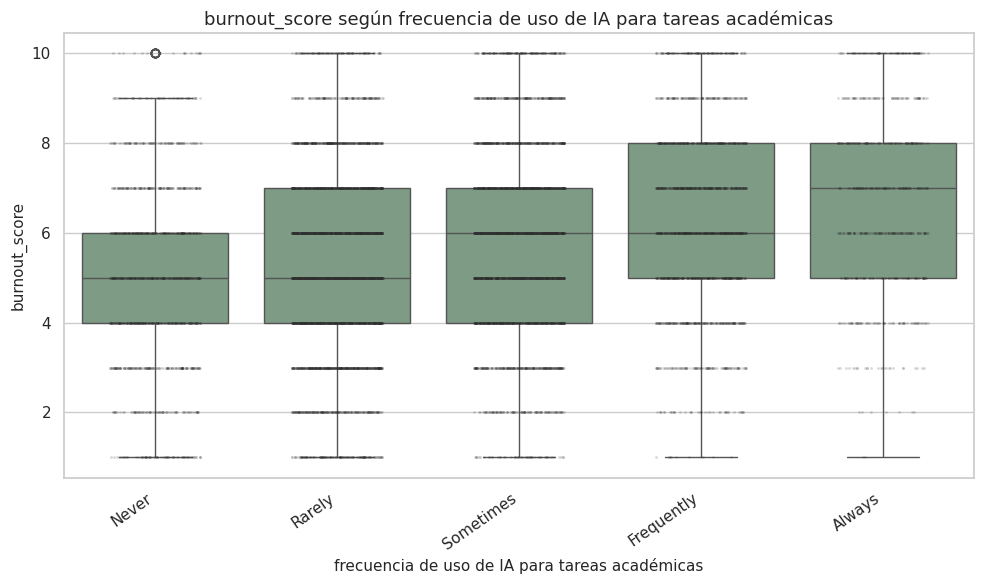

### herramienta principal de IA utilizada

,primary_ai_tools_used,count,mean,median,std,min,max
0,ChatGPT,5156,5.61,6.0,2.05,1,10
1,Claude,1779,5.63,6.0,2.07,1,10
2,Gemini,2331,5.47,5.0,2.05,1,10
3,GitHub Copilot,902,6.34,6.0,2.01,1,10
4,Perplexity,951,5.60,6.0,2.09,1,10


**Interpretación de tamaños de grupo para herramienta principal de IA utilizada:**

La media más alta de burnout aparece en `GitHub Copilot` (media = 6.34, n = 902).

La media más baja aparece en `Gemini` (media = 5.47, n = 2331).

Todas las categorías tienen al menos 30 registros, por lo que las comparaciones descriptivas tienen un respaldo razonable en tamaño muestral.

Estas diferencias son descriptivas; no constituyen evidencia causal ni una prueba estadística inferencial.

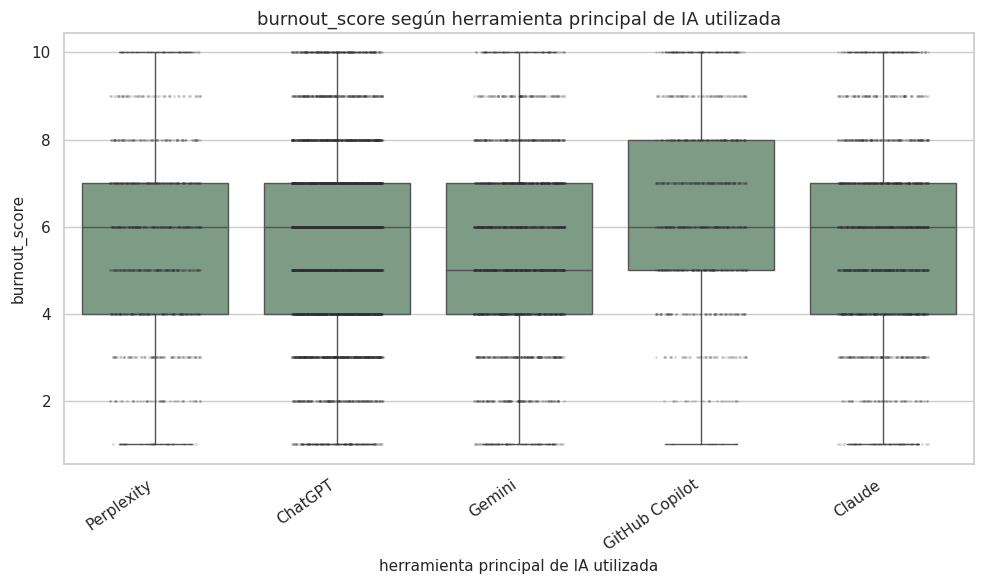

### área de estudio

,stream,count,mean,median,std,min,max
0,Arts/Sciences,1436,5.45,5.0,2.09,1,10
1,CS/IT,5445,5.87,6.0,2.04,1,10
2,Commerce/Management,1844,5.40,5.0,2.07,1,10
3,Engineering (Non-CS),2394,5.43,5.0,2.05,1,10


**Interpretación de tamaños de grupo para área de estudio:**

La media más alta de burnout aparece en `CS/IT` (media = 5.87, n = 5445).

La media más baja aparece en `Commerce/Management` (media = 5.40, n = 1844).

Todas las categorías tienen al menos 30 registros, por lo que las comparaciones descriptivas tienen un respaldo razonable en tamaño muestral.

Estas diferencias son descriptivas; no constituyen evidencia causal ni una prueba estadística inferencial.

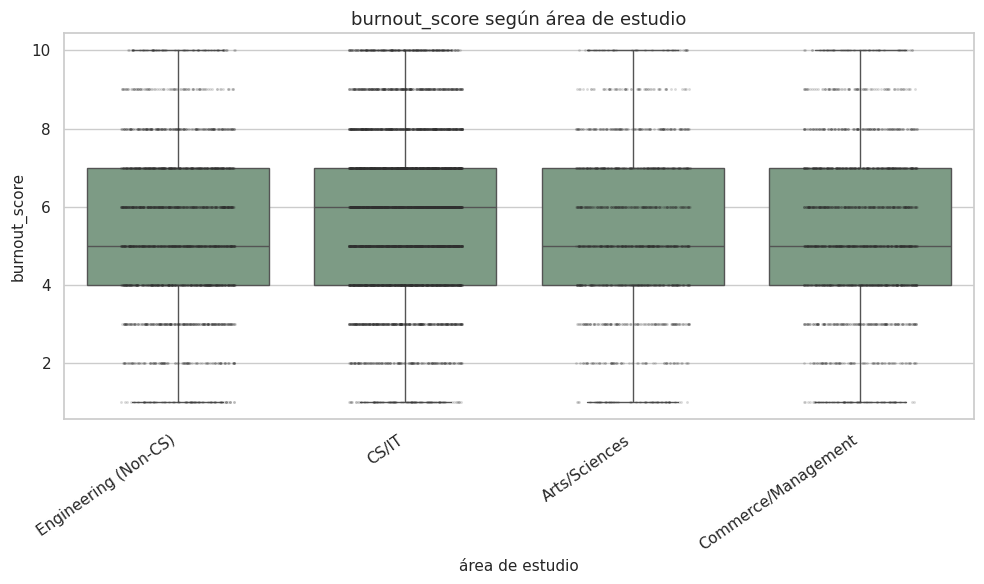

### tipo de institución

,college_tier,count,mean,median,std,min,max
0,Tier 1,1656,5.30,5.0,2.05,1,10
1,Tier 2,3915,5.62,6.0,2.06,1,10
2,Tier 3,5548,5.76,6.0,2.06,1,10


**Interpretación de tamaños de grupo para tipo de institución:**

La media más alta de burnout aparece en `Tier 3` (media = 5.76, n = 5548).

La media más baja aparece en `Tier 1` (media = 5.30, n = 1656).

Todas las categorías tienen al menos 30 registros, por lo que las comparaciones descriptivas tienen un respaldo razonable en tamaño muestral.

Estas diferencias son descriptivas; no constituyen evidencia causal ni una prueba estadística inferencial.

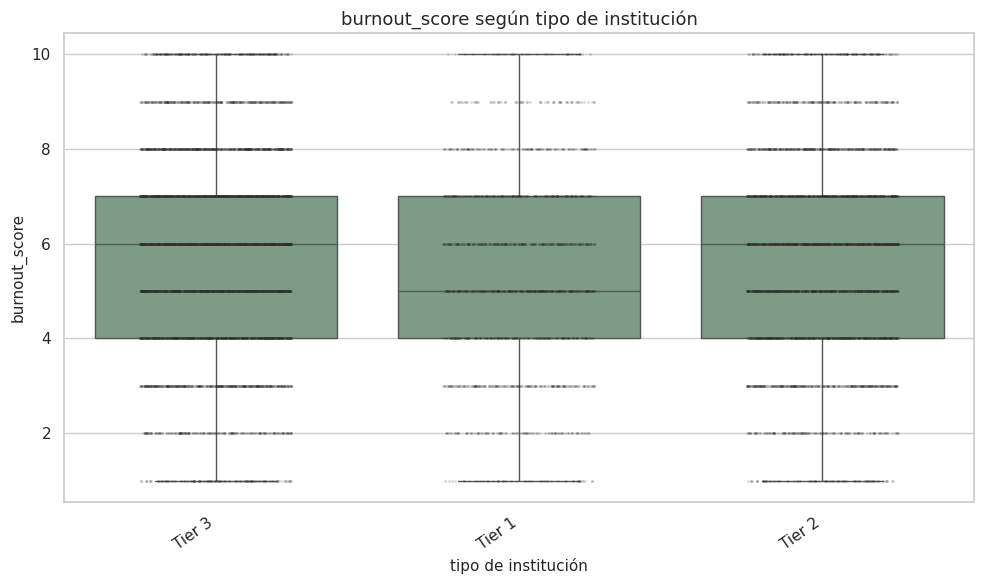

### búsqueda de orientación profesional

,seeks_career_counseling_label,count,mean,median,std,min,max
0,No busca orientación,7881,5.13,5.0,1.93,1,10
1,Busca orientación,3238,6.89,7.0,1.83,1,10


**Interpretación de tamaños de grupo para búsqueda de orientación profesional:**

La media más alta de burnout aparece en `Busca orientación` (media = 6.89, n = 3238).

La media más baja aparece en `No busca orientación` (media = 5.13, n = 7881).

Todas las categorías tienen al menos 30 registros, por lo que las comparaciones descriptivas tienen un respaldo razonable en tamaño muestral.

Aunque la diferencia es relevante, esta variable puede ser consecuencia o señal de búsqueda de apoyo ante el malestar, por lo que no debe leerse automáticamente como causa del burnout.

Estas diferencias son descriptivas; no constituyen evidencia causal ni una prueba estadística inferencial.

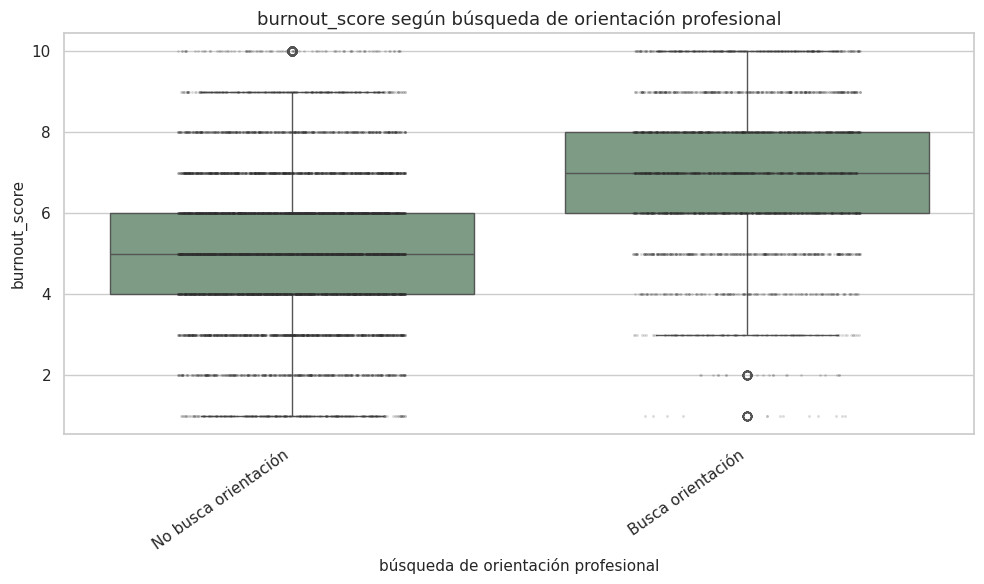

In [11]:
def interpret_group_summary(variable: str, label: str) -> str:
    summary = summaries[variable].copy()
    group_col = summary.columns[0]
    highest = summary.sort_values("mean", ascending=False).iloc[0]
    lowest = summary.sort_values("mean", ascending=True).iloc[0]
    small_groups = summary[summary["count"] < MIN_GROUP_SIZE_FOR_INTERPRETATION]

    lines = [
        f"**Interpretación de tamaños de grupo para {label}:**",
        f"La media más alta de burnout aparece en `{highest[group_col]}` (media = {highest['mean']:.2f}, n = {int(highest['count'])}).",
        f"La media más baja aparece en `{lowest[group_col]}` (media = {lowest['mean']:.2f}, n = {int(lowest['count'])}).",
    ]
    if small_groups.empty:
        lines.append(
            f"Todas las categorías tienen al menos {MIN_GROUP_SIZE_FOR_INTERPRETATION} registros, "
            "por lo que las comparaciones descriptivas tienen un respaldo razonable en tamaño muestral."
        )
    else:
        groups = ", ".join(
            f"`{row[group_col]}` (n = {int(row['count'])})"
            for _, row in small_groups.iterrows()
        )
        lines.append(
            "Las siguientes categorías tienen pocos registros y sus medias deben interpretarse con cautela: "
            f"{groups}."
        )
    if variable == "seeks_career_counseling_label":
        lines.append(
            "Aunque la diferencia es relevante, esta variable puede ser consecuencia o señal de búsqueda de apoyo "
            "ante el malestar, por lo que no debe leerse automáticamente como causa del burnout."
        )
    lines.append("Estas diferencias son descriptivas; no constituyen evidencia causal ni una prueba estadística inferencial.")
    return "\n\n".join(lines)

def show_group_analysis(variable: str, label: str, filename: str, order=None):
    display(Markdown(f"### {label}"))
    display(summaries[variable])
    display(Markdown(interpret_group_summary(variable, label)))

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=analysis_df,
        x=variable,
        y=TARGET,
        order=order,
        color="#78a083",
    )
    sns.stripplot(
        data=analysis_df,
        x=variable,
        y=TARGET,
        order=order,
        color="#2f2f2f",
        alpha=0.18,
        size=2,
        jitter=0.25,
    )
    plt.title(f"{TARGET} según {label}")
    plt.xlabel(label)
    plt.ylabel(TARGET)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

show_group_analysis(
    "uses_ai_for_assignments",
    "frecuencia de uso de IA para tareas académicas",
    "burnout_por_uso_ia.csv",
    order=AI_USAGE_ORDER,
)

show_group_analysis(
    "primary_ai_tools_used",
    "herramienta principal de IA utilizada",
    "burnout_por_herramienta_ia.csv",
)

show_group_analysis(
    "stream",
    "área de estudio",
    "burnout_por_stream.csv",
)

show_group_analysis(
    "college_tier",
    "tipo de institución",
    "burnout_por_college_tier.csv",
)

show_group_analysis(
    "seeks_career_counseling_label",
    "búsqueda de orientación profesional",
    "burnout_por_orientacion_carrera.csv",
    order=CAREER_COUNSELING_ORDER,
)

## 6. Tabla final de variables candidatas para modelamiento

Esta tabla sintetiza variables que podrían considerarse en una etapa posterior de machine learning. La selección combina fuerza de asociación observada y relevancia conceptual para la problemática.

La columna `valor_observado` no representa una única métrica para todos los tipos de variable: en variables numéricas corresponde a la correlación Spearman con `burnout_score`, mientras que en variables categóricas corresponde a la diferencia entre la media más alta y la media más baja de burnout entre grupos. Por eso la tabla incluye `metrica_observada` y `descripcion_metrica`.

In [12]:
conceptual_priority = {
    "stress_level": "Bienestar personal; hipótesis espera asociación positiva con burnout.",
    "motivation_score": "Bienestar/motivación; hipótesis espera asociación negativa con burnout.",
    "ai_dependency_score": "Dependencia de IA; eje central de la problemática.",
    "placement_anxiety_score": "Ansiedad profesional; eje central de la problemática.",
    "interview_anxiety_score": "Ansiedad profesional específica ante entrevistas.",
    "fear_of_job_loss_to_ai": "Temor a pérdida laboral por IA; relevante para ansiedad profesional y aparece en el ranking de correlaciones.",
    "daily_ai_tool_usage_hrs": "Intensidad de uso de IA; relevante para hábitos académicos.",
    "sleep_hours": "Hábito de bienestar; posible relación protectora.",
    "seeks_career_counseling": "Búsqueda de orientación profesional; asociación relevante, pero debe interpretarse con cautela porque puede ser respuesta al malestar.",
    "overall_career_readiness_score": "Preparación profesional general; posible relación con ansiedad y burnout.",
}

candidate_rows = []
for var, justification in conceptual_priority.items():
    corr = ranking_correlaciones.loc[
        ranking_correlaciones["variable"] == var, "correlacion_spearman"
    ].iloc[0]
    candidate_rows.append({
        "variable": var,
        "tipo": "binaria" if var == "seeks_career_counseling" else "numérica",
        "metrica_observada": "Spearman con burnout_score",
        "valor_observado": round(float(corr), 3),
        "direccion_observada": "positiva" if corr > 0 else "negativa",
        "descripcion_metrica": "Correlación monotónica; valores entre -1 y 1.",
        "justificacion": justification,
    })

for var, label in [
    ("uses_ai_for_assignments", "Frecuencia de uso de IA en tareas académicas."),
    ("primary_ai_tools_used", "Herramienta principal de IA utilizada."),
    ("stream", "Área de estudio."),
    ("college_tier", "Contexto institucional."),
]:
    summary = summaries[var]
    spread = summary["mean"].max() - summary["mean"].min()
    candidate_rows.append({
        "variable": var,
        "tipo": "categórica" if var != "seeks_career_counseling_label" else "binaria agrupada",
        "metrica_observada": "Diferencia entre medias de burnout",
        "valor_observado": round(float(spread), 3),
        "direccion_observada": "diferencia entre grupos",
        "descripcion_metrica": "Media máxima de burnout menos media mínima entre categorías; no es una correlación.",
        "justificacion": f"{label} Diferencia descriptiva entre medias de burnout = {spread:.2f}; revisar junto con count por categoría.",
    })

variables_candidatas_modelamiento = pd.DataFrame(candidate_rows)
variables_candidatas_modelamiento.to_csv(
    OUTPUT_TABLES_DIR / "variables_candidatas_modelamiento.csv",
    index=False,
)
display(variables_candidatas_modelamiento)

,variable,tipo,metrica_observada,valor_observado,direccion_observada,descripcion_metrica,justificacion
0,stress_level,numérica,Spearman con burnout_score,0.577,positiva,Correlación monotónica; valores entre -1 y 1.,Bienestar personal; hipótesis espera asociació...
1,motivation_score,numérica,Spearman con burnout_score,-0.524,negativa,Correlación monotónica; valores entre -1 y 1.,Bienestar/motivación; hipótesis espera asociac...
2,ai_dependency_score,numérica,Spearman con burnout_score,0.351,positiva,Correlación monotónica; valores entre -1 y 1.,Dependencia de IA; eje central de la problemát...
3,placement_anxiety_score,numérica,Spearman con burnout_score,0.370,positiva,Correlación monotónica; valores entre -1 y 1.,Ansiedad profesional; eje central de la proble...
4,interview_anxiety_score,numérica,Spearman con burnout_score,0.356,positiva,Correlación monotónica; valores entre -1 y 1.,Ansiedad profesional específica ante entrevistas.
5,fear_of_job_loss_to_ai,numérica,Spearman con burnout_score,0.355,positiva,Correlación monotónica; valores entre -1 y 1.,Temor a pérdida laboral por IA; relevante para...
6,daily_ai_tool_usage_hrs,numérica,Spearman con burnout_score,0.225,positiva,Correlación monotónica; valores entre -1 y 1.,Intensidad de uso de IA; relevante para hábito...
7,sleep_hours,numérica,Spearman con burnout_score,-0.167,negativa,Correlación monotónica; valores entre -1 y 1.,Hábito de bienestar; posible relación protectora.
8,seeks_career_counseling,binaria,Spearman con burnout_score,0.386,positiva,Correlación monotónica; valores entre -1 y 1.,Búsqueda de orientación profesional; asociació...
9,overall_career_readiness_score,numérica,Spearman con burnout_score,-0.170,negativa,Correlación monotónica; valores entre -1 y 1.,Preparación profesional general; posible relac...


## 7. Conclusiones y hallazgos principales

Esta sección resume los patrones observados, las variables candidatas para modelamiento y las principales limitaciones del análisis.

In [13]:
def get_corr(variable: str) -> float:
    return ranking_correlaciones.loc[
        ranking_correlaciones["variable"] == variable,
        "correlacion_spearman",
    ].iloc[0]

def group_extremes(variable: str):
    summary = summaries[variable].copy()
    group_col = summary.columns[0]
    highest = summary.sort_values("mean", ascending=False).iloc[0]
    lowest = summary.sort_values("mean", ascending=True).iloc[0]
    return group_col, highest, lowest

def final_conclusions() -> str:
    top = ranking_correlaciones.head(5)
    top_txt = ", ".join(
        f"`{row.variable}` ({row.correlacion_spearman:.3f})"
        for row in top.itertuples(index=False)
    )

    stress_corr = get_corr("stress_level")
    motivation_corr = get_corr("motivation_score")
    ai_dep_corr = get_corr("ai_dependency_score")
    placement_corr = get_corr("placement_anxiety_score")
    counseling_corr = get_corr("seeks_career_counseling")
    fear_corr = get_corr("fear_of_job_loss_to_ai")

    usage_summary = summaries["uses_ai_for_assignments"]
    usage_never = usage_summary.loc[usage_summary["uses_ai_for_assignments"] == "Never", "mean"].iloc[0]
    usage_always = usage_summary.loc[usage_summary["uses_ai_for_assignments"] == "Always", "mean"].iloc[0]

    _, tool_high, tool_low = group_extremes("primary_ai_tools_used")
    _, stream_high, stream_low = group_extremes("stream")
    _, tier_high, tier_low = group_extremes("college_tier")
    _, counseling_high, counseling_low = group_extremes("seeks_career_counseling_label")

    hypothesis_parts = []
    hypothesis_parts.append("estrés" if stress_corr > 0 else "estrés no muestra la dirección esperada")
    hypothesis_parts.append("motivación" if motivation_corr < 0 else "motivación no muestra la dirección esperada")
    hypothesis_parts.append("dependencia de IA" if ai_dep_corr > 0 else "dependencia de IA no muestra la dirección esperada")
    hypothesis_parts.append("ansiedad profesional" if placement_corr > 0 else "ansiedad profesional no muestra la dirección esperada")

    return f"""
### Síntesis final

Las variables numéricas más relacionadas con `{TARGET}` según Spearman son: {top_txt}. Además, `fear_of_job_loss_to_ai` mantiene una asociación positiva con burnout (Spearman = {fear_corr:.3f}) y se incorpora como candidata porque conecta conceptualmente con la ansiedad profesional frente a la IA.

Respecto de la hipótesis inicial, el análisis permite revisar especialmente los patrones asociados a {", ".join(hypothesis_parts)}. En conjunto, las direcciones observadas respaldan la hipótesis exploratoria: mayor estrés, mayor dependencia de IA y mayor ansiedad profesional tienden a coexistir con mayor burnout, mientras que mayor motivación tiende a coexistir con menor burnout.

En las comparaciones por grupos, la frecuencia de uso de IA para tareas académicas muestra un patrón creciente: quienes nunca usan IA presentan un burnout medio de {usage_never:.2f}, mientras que quienes la usan siempre presentan una media de {usage_always:.2f}. También se observa mayor burnout promedio en usuarios de `{tool_high['primary_ai_tools_used']}` ({tool_high['mean']:.2f}), estudiantes de `{stream_high['stream']}` ({stream_high['mean']:.2f}) e instituciones `{tier_high['college_tier']}` ({tier_high['mean']:.2f}). Como contraste, los grupos con menor media son `{tool_low['primary_ai_tools_used']}` ({tool_low['mean']:.2f}), `{stream_low['stream']}` ({stream_low['mean']:.2f}) y `{tier_low['college_tier']}` ({tier_low['mean']:.2f}).

`seeks_career_counseling` también presenta una asociación relevante con `{TARGET}`: su Spearman es {counseling_corr:.3f}, y el grupo `{counseling_high['seeks_career_counseling_label']}` tiene burnout medio de {counseling_high['mean']:.2f}, frente a {counseling_low['mean']:.2f} en `{counseling_low['seeks_career_counseling_label']}`. Este resultado debe tratarse con cautela porque buscar orientación puede ser una consecuencia o señal de malestar previo, no necesariamente una causa del burnout.

Variables candidatas para modelamiento: `stress_level`, `motivation_score`, `ai_dependency_score`, `placement_anxiety_score`, `interview_anxiety_score`, `fear_of_job_loss_to_ai`, `daily_ai_tool_usage_hrs`, `sleep_hours`, `seeks_career_counseling`, `overall_career_readiness_score`, `uses_ai_for_assignments`, `primary_ai_tools_used`, `stream` y `college_tier`.

Limitaciones: este notebook realiza análisis bivariado exploratorio, no entrena modelos, no controla interacciones entre variables, no aplica pruebas inferenciales y no permite afirmar causalidad. Además, variables como `stress_level`, `motivation_score` y `overall_career_readiness_score` están conceptualmente cercanas al burnout; en modelamiento se recomienda comparar versiones con y sin estas variables para evaluar cuánto aportan frente a predictores menos directamente ligados al bienestar.

Dado que `burnout_score` se mantiene como variable numérica, la siguiente etapa podría abordarse inicialmente como un problema de regresión. Alternativamente, si se definen umbrales de burnout bajo, medio y alto, podría transformarse en un problema de clasificación.
"""

display(Markdown(final_conclusions()))


### Síntesis final

Las variables numéricas más relacionadas con `burnout_score` según Spearman son: `stress_level` (0.577), `motivation_score` (-0.524), `seeks_career_counseling` (0.386), `placement_anxiety_score` (0.370), `interview_anxiety_score` (0.356). Además, `fear_of_job_loss_to_ai` mantiene una asociación positiva con burnout (Spearman = 0.355) y se incorpora como candidata porque conecta conceptualmente con la ansiedad profesional frente a la IA.

Respecto de la hipótesis inicial, el análisis permite revisar especialmente los patrones asociados a estrés, motivación, dependencia de IA, ansiedad profesional. En conjunto, las direcciones observadas respaldan la hipótesis exploratoria: mayor estrés, mayor dependencia de IA y mayor ansiedad profesional tienden a coexistir con mayor burnout, mientras que mayor motivación tiende a coexistir con menor burnout.

En las comparaciones por grupos, la frecuencia de uso de IA para tareas académicas muestra un patrón creciente: quienes nunca usan IA presentan un burnout medio de 5.00, mientras que quienes la usan siempre presentan una media de 6.64. También se observa mayor burnout promedio en usuarios de `GitHub Copilot` (6.34), estudiantes de `CS/IT` (5.87) e instituciones `Tier 3` (5.76). Como contraste, los grupos con menor media son `Gemini` (5.47), `Commerce/Management` (5.40) y `Tier 1` (5.30).

`seeks_career_counseling` también presenta una asociación relevante con `burnout_score`: su Spearman es 0.386, y el grupo `Busca orientación` tiene burnout medio de 6.89, frente a 5.13 en `No busca orientación`. Este resultado debe tratarse con cautela porque buscar orientación puede ser una consecuencia o señal de malestar previo, no necesariamente una causa del burnout.

Variables candidatas para modelamiento: `stress_level`, `motivation_score`, `ai_dependency_score`, `placement_anxiety_score`, `interview_anxiety_score`, `fear_of_job_loss_to_ai`, `daily_ai_tool_usage_hrs`, `sleep_hours`, `seeks_career_counseling`, `overall_career_readiness_score`, `uses_ai_for_assignments`, `primary_ai_tools_used`, `stream` y `college_tier`.

Limitaciones: este notebook realiza análisis bivariado exploratorio, no entrena modelos, no controla interacciones entre variables, no aplica pruebas inferenciales y no permite afirmar causalidad. Además, variables como `stress_level`, `motivation_score` y `overall_career_readiness_score` están conceptualmente cercanas al burnout; en modelamiento se recomienda comparar versiones con y sin estas variables para evaluar cuánto aportan frente a predictores menos directamente ligados al bienestar.

Dado que `burnout_score` se mantiene como variable numérica, la siguiente etapa podría abordarse inicialmente como un problema de regresión. Alternativamente, si se definen umbrales de burnout bajo, medio y alto, podría transformarse en un problema de clasificación.
